# Simulation Notebook 6

# Faces with JAX attractor network

This notebook demonstrates **storage of face images** in the FEP attractor network (JAX implementation), **attractor dynamics**, and **reconstruction** from noisy input.

## Outline

1. **Data**: Load Olivetti faces (sklearn), downsample to keep runtime tractable, normalize to obtain patterns.
2. **Training**: Store face patterns in the network using the same local learning rule as in the scaling notebook.
3. **Attractors**: Evaluate deterministic retention (free run from stored pattern).
4. **Reconstruction**: Present noisy versions of stored faces as continuous bias; compare correlation of noisy input vs. reconstructed output with the original pattern.

Equations use the same notation as the manuscript: pattern $\mathbf{u}$, activations $\mathbf{x}$, coupling $\mathbf{W}$, and variational free energy (VFE) driving both inference and learning.

In [1]:
# Backend guard: force CPU (run before importing jax)
import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ.pop("ENABLE_PJRT_COMPATIBILITY", None)
print("Configured JAX_PLATFORMS=cpu")

Configured JAX_PLATFORMS=cpu


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import sobel
from sklearn.datasets import fetch_olivetti_faces

from simulation.network_jax import JAXAttractorNetwork

## 1. Load and prepare face patterns

Olivetti faces: 400 images, 64×64 pixels. We downsample to 32×32 (1024 nodes) for tractable training. The network models **binary evidence** (for vs. against) at each node, so we preprocess images into **binary edge maps**: Sobel edge detection is applied, then gradient magnitude is thresholded to obtain $\{-1, +1\}$ patterns (edge = +1, no edge = −1). Faces remain recognizable from these edge maps. Flattened binary patterns are used for training and inference.

In [3]:
def grayscale_to_binary_edges(images_3d, edge_percentile=90):
    """
    Convert (n, h, w) grayscale images to binary edge maps in {-1, +1}.
    Edge pixels (high gradient magnitude) = +1, non-edge = -1.
    Uses Sobel; threshold is per-image percentile so faces stay recognizable.
    """
    n, h, w = images_3d.shape
    out = np.empty((n, h, w), dtype=np.float64)
    for i in range(n):
        gx = sobel(images_3d[i], axis=1)
        gy = sobel(images_3d[i], axis=0)
        mag = np.sqrt(gx.astype(np.float64) ** 2 + gy.astype(np.float64) ** 2)
        thresh = np.percentile(mag, edge_percentile)
        out[i] = np.where(mag >= thresh, 1.0, -1.0)
    return -1*out


def load_faces(subsample_size=64, n_max=np.inf, seed=0, binary_edges=False, edge_percentile=75):
    """Load Olivetti faces, downsample, optionally convert to binary edge maps; return (n, d) patterns."""
    data = fetch_olivetti_faces()
    images = data["images"]  # (400, 64, 64)
    step = 64 // subsample_size
    small = images[:, ::step, ::step]  # (n, h, w)
    n, h, w = small.shape
    n_keep = int(np.min((n, n_max)))
    if n_keep < n:
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=n_keep, replace=False)
        small = small[idx]
    n = n_keep
    if binary_edges:
        binary_3d = grayscale_to_binary_edges(small, edge_percentile=edge_percentile)
        flat = binary_3d.reshape(n, -1).astype(np.float64)  # values in {-1, +1}
        flat = (flat - flat.mean(axis=1, keepdims=True)) / (flat.std(axis=1, keepdims=True) + 1e-8)
    else:
        flat = small.reshape(n, -1).astype(np.float64)
        flat = (flat - flat.mean(axis=1, keepdims=True)) / (flat.std(axis=1, keepdims=True) + 1e-8)
    return flat, (h, w)


patterns, shape = load_faces(n_max=np.inf, binary_edges=False, edge_percentile=75)
n_patterns, n_nodes = patterns.shape
print(f"Patterns: {n_patterns}, nodes: {n_nodes}, shape: {shape} (binary edge maps in {{-1, +1}})")

Patterns: 400, nodes: 4096, shape: (64, 64) (binary edge maps in {-1, +1})


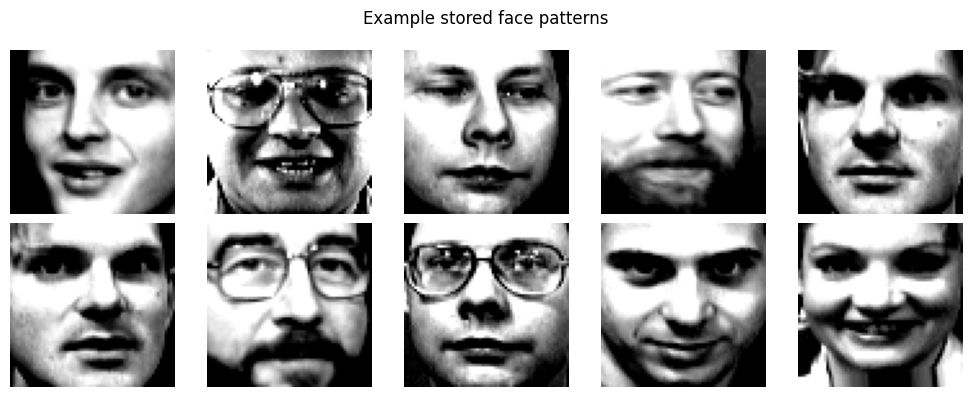

In [4]:
# Show a few stored faces (random selection)
rng_faces = np.random.default_rng(42)
idx_show = rng_faces.choice(len(patterns), size=10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
# Binary patterns in {-1, +1}; use fixed range for consistent contrast
for i, ax in enumerate(axes.flat):
    ax.imshow(patterns[idx_show[i]].reshape(shape), cmap="gray", vmin=-1, vmax=1)
    ax.set_axis_off()
plt.suptitle("Example stored face patterns")
plt.tight_layout(pad=0.02, w_pad=0.02, h_pad=0.02)
plt.show()

## 2. Train network to store faces

Same training protocol as in the scaling notebook: random pattern presentation, evidence level scales the input, local VFE-based updates.

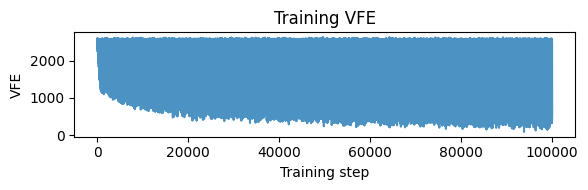

In [5]:
cfg = {
    "evidence_level": 1.0,
    "beta": 0.7, #0.5
    "lr": 0.0001,
    "epochs": 10000,
    "steps": 10,
    "seed": 42,
}

jnet = JAXAttractorNetwork(n_nodes=n_nodes, seed=cfg["seed"])
vfe_hist = jnet.train(
    patterns,
    evidence_level=cfg["evidence_level"],
    beta=cfg["beta"],
    lr=cfg["lr"],
    epochs=cfg["epochs"],
    steps=cfg["steps"],
)

plt.figure(figsize=(6, 2))
plt.plot(np.asarray(vfe_hist), alpha=0.8)
plt.xlabel("Training step")
plt.ylabel("VFE")
plt.title("Training VFE")
plt.tight_layout(pad=0.02, w_pad=0.02, h_pad=0.02)
plt.show()

## 3. Attractor retention

Start from each stored pattern and run **deterministic** inference with **no external bias** ($\mathbf{u}=\mathbf{0}$). The final state should remain close to the pattern if it lies near an attractor.

In [6]:
def _safe_corr(a, b):
    c = np.corrcoef(a, b)[0, 1]
    return 0.0 if np.isnan(c) else float(c)


def retention_jax(jnet, patterns, infer_beta=10.0, steps=150):
    """Mean correlation between relaxed state and original pattern (free run, no bias)."""
    n = patterns.shape[1]
    scores = []
    for p in patterns:
        acts, _ = jnet.infer(x0=p, u=np.zeros(n), beta=infer_beta, steps=steps, stochastic=False)
        out = np.asarray(acts[-1])
        scores.append(_safe_corr(out, p))
    return float(np.mean(scores))


retention = retention_jax(jnet, patterns, infer_beta=100.0, steps=150)
print(f"Mean retention correlation (stored pattern vs attractor): {retention:.4f}")

Mean retention correlation (stored pattern vs attractor): 0.4658


### Visualize attractors

For a few stored patterns, run deterministic free dynamics ($\mathbf{u}=\mathbf{0}$) and show the **stored pattern** vs the **attractor** (final state). If the pattern is stored as an attractor, the two should match closely.

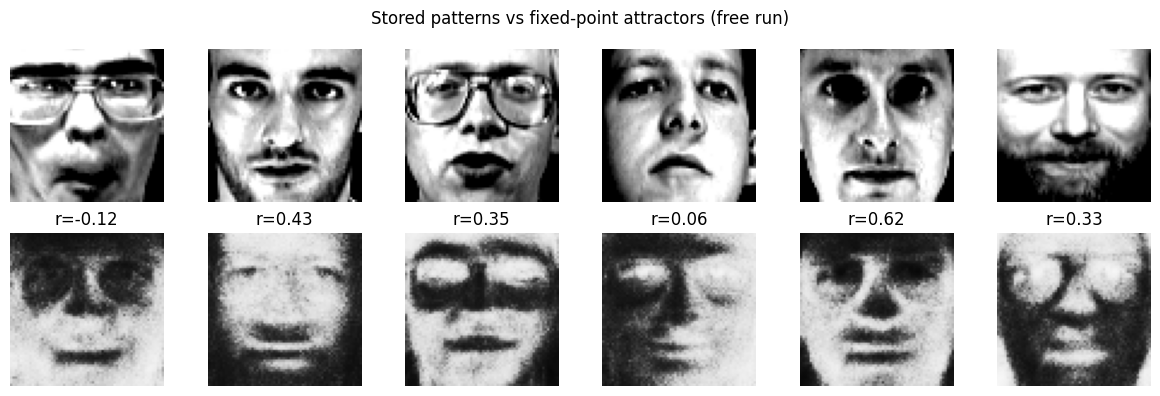

In [7]:
n_show_att = 6
rng_att = np.random.default_rng(43)
idx_att = rng_att.choice(len(patterns), size=n_show_att, replace=False)
fig, axes = plt.subplots(2, n_show_att, figsize=(2 * n_show_att, 4))
for j in range(n_show_att):
    p = patterns[idx_att[j]]
    acts, _ = jnet.infer(x0=p, u=np.zeros(n_nodes), beta=1, steps=150, stochastic=False)
    attractor = np.asarray(acts[-1])
    axes[0, j].imshow(p.reshape(shape), cmap="gray", vmin=-1, vmax=1)
    axes[0, j].set_axis_off()
    axes[1, j].imshow(attractor.reshape(shape), cmap="gray", vmin=-1, vmax=1)
    axes[1, j].set_axis_off()
    corr = _safe_corr(attractor, p)
    axes[1, j].set_title(f"r={corr:.2f}")
axes[0, 0].set_ylabel("Stored pattern")
axes[1, 0].set_ylabel("Attractor")
plt.suptitle("Stored patterns vs fixed-point attractors (free run)")
plt.tight_layout(pad=0.02, w_pad=0.02, h_pad=0.02)
plt.show()

### Alternative retention: random restarts and unique attractors

Another way to assess attractors: **initialize with noise**, run **deterministic** relaxation until **convergence** (change below a tolerance), **repeat many times**, then keep only **unique** fixed points (within a tolerance). Plot the unique attractors.

Restarts: 200 → 52 unique attractors (tol=0.2)


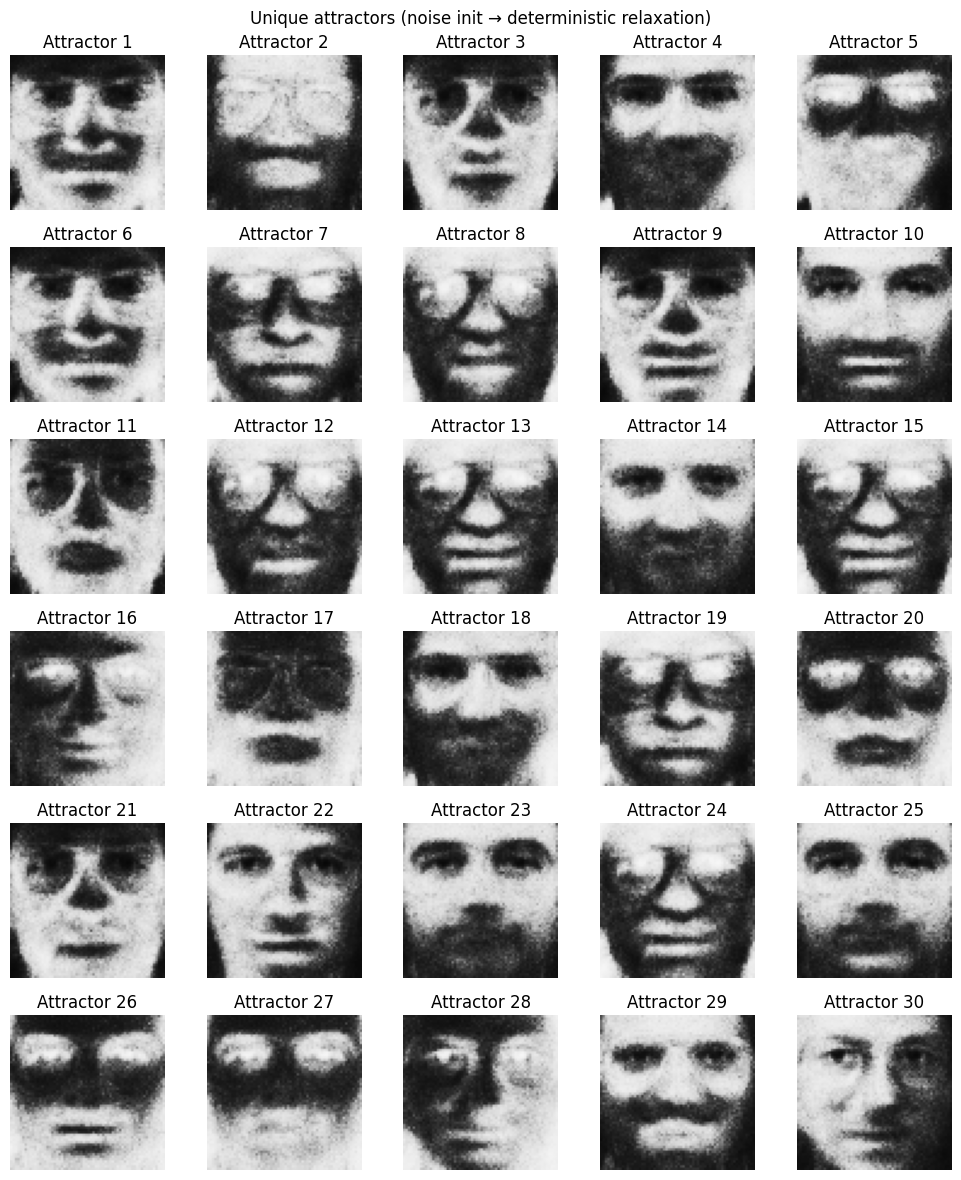

In [8]:
def relax_until_converged(jnet, x0, u, beta, tol=1e-4, max_steps=500):
    """Deterministic relaxation until max|x_new - x_prev| < tol or max_steps reached."""
    x = np.asarray(x0, dtype=jnet.W.dtype)
    u = np.asarray(u, dtype=jnet.W.dtype) if u is not None else np.zeros_like(x)
    for _ in range(max_steps):
        acts, _ = jnet.infer(x0=x, u=u, beta=beta, steps=1, stochastic=False)
        x_new = np.asarray(acts[-1])
        if np.max(np.abs(x_new - x)) < tol:
            return x_new
        x = x_new
    return x_new


def unique_attractors(attractor_list, tol_unique=0.05):
    """Deduplicate attractors: two are the same if max|a - b| < tol_unique."""
    unique = []
    for a in attractor_list:
        a = np.asarray(a).ravel()
        is_new = True
        for b in unique:
            if np.max(np.abs(np.asarray(b).ravel() - a)) < tol_unique:
                is_new = False
                break
        if is_new:
            unique.append(a)
    return unique


# Parameters
n_restarts = 200
infer_beta = 1.0
conv_tol = 1e-5
conv_max_steps = 500
tol_unique = 0.2
rng_restart = np.random.default_rng(44)

# Random initial states in [-1, 1], then relax to convergence
raw_attractors = []
for _ in range(n_restarts):
    x0 = rng_restart.uniform(-1, 1, size=n_nodes).astype(np.float32)
    x_final = relax_until_converged(jnet, x0, np.zeros(n_nodes), infer_beta, tol=conv_tol, max_steps=conv_max_steps)
    raw_attractors.append(x_final)

unique = unique_attractors(raw_attractors, tol_unique=tol_unique)
print(f"Restarts: {n_restarts} → {len(unique)} unique attractors (tol={tol_unique})")

# Plot unique attractors (up to 15 in a grid)
n_show = min(30, len(unique))
n_col = 5
n_row = (n_show + n_col - 1) // n_col
fig, axes = plt.subplots(n_row, n_col, figsize=(2 * n_col, 2 * n_row))
axes = axes.ravel()
for i in range(n_show):
    axes[i].imshow(unique[i].reshape(shape), cmap="gray", vmin=-1, vmax=1)
    axes[i].set_axis_off()
    axes[i].set_title(f"Attractor {i+1}")
for i in range(n_show, len(axes)):
    axes[i].set_axis_off()
plt.suptitle("Unique attractors (noise init → deterministic relaxation)")
plt.tight_layout(pad=0.02, w_pad=0.02, h_pad=0.02)
plt.show()

## 4. Noisy reconstruction

For each stored pattern, add Gaussian noise to form a noisy cue. Run **stochastic** inference with the **noisy pattern as continuous bias** $\mathbf{u}$. The mean activity after burn-in is the reconstruction; we expect correlation with the original to be higher than the correlation of the noisy input with the original (reconstruction gain).

In [9]:
def noisy_reconstruction_jax(jnet, patterns, noise_std=2.0, infer_beta=1.0, recon_steps=25, burn_in=5, repeats=1, seed=0):
    """Noisy input as bias; report mean noisy correlation and mean reconstructed correlation with original."""
    rng = np.random.default_rng(seed)
    n = patterns.shape[1]
    noisy_corrs, recon_corrs = [], []
    start_idx = min(max(0, burn_in), max(0, recon_steps - 1))
    for p in patterns:
        for _ in range(repeats):
            noisy = p + rng.normal(0.0, noise_std * np.std(p), size=p.shape)
            noisy_corrs.append(_safe_corr(noisy, p))
            acts, _ = jnet.infer(x0=noisy, u=noisy, beta=infer_beta, steps=recon_steps, stochastic=True)
            acts = np.asarray(acts)
            mean_pattern = acts[start_idx:].mean(axis=0)
            recon_corrs.append(_safe_corr(mean_pattern, p))
    return float(np.mean(noisy_corrs)), float(np.mean(recon_corrs))


noisy_corr, recon_corr = noisy_reconstruction_jax(
    jnet, patterns, noise_std=2.0, infer_beta=2.0, recon_steps=100, burn_in=5, seed=cfg["seed"] + 1000
)
gain = recon_corr - noisy_corr
print(f"Noisy input vs original:  corr = {noisy_corr:.4f}")
print(f"Reconstructed vs original: corr = {recon_corr:.4f}")
print(f"Reconstruction gain: {gain:.4f}")

Noisy input vs original:  corr = 0.4479
Reconstructed vs original: corr = 0.7580
Reconstruction gain: 0.3100


## 5. Visualize reconstruction

For a few faces: show **original**, **noisy input**, and **reconstructed** (mean activity under noisy bias).

In [10]:
def reconstruct_one(jnet, original, noise_std=2.0, signal_strength=0.5, infer_beta=1.0, steps=500, burn_in=10, seed=0):
    rng = np.random.default_rng(seed)
    noisy = original + rng.normal(0.0, noise_std * np.std(original), size=original.shape)
    noisy *= signal_strength
    acts, _ = jnet.infer(x0=noisy, u=noisy, beta=infer_beta, steps=steps, stochastic=True)
    acts = np.asarray(acts)
    recon = acts[burn_in:].mean(axis=0)
    return noisy, recon


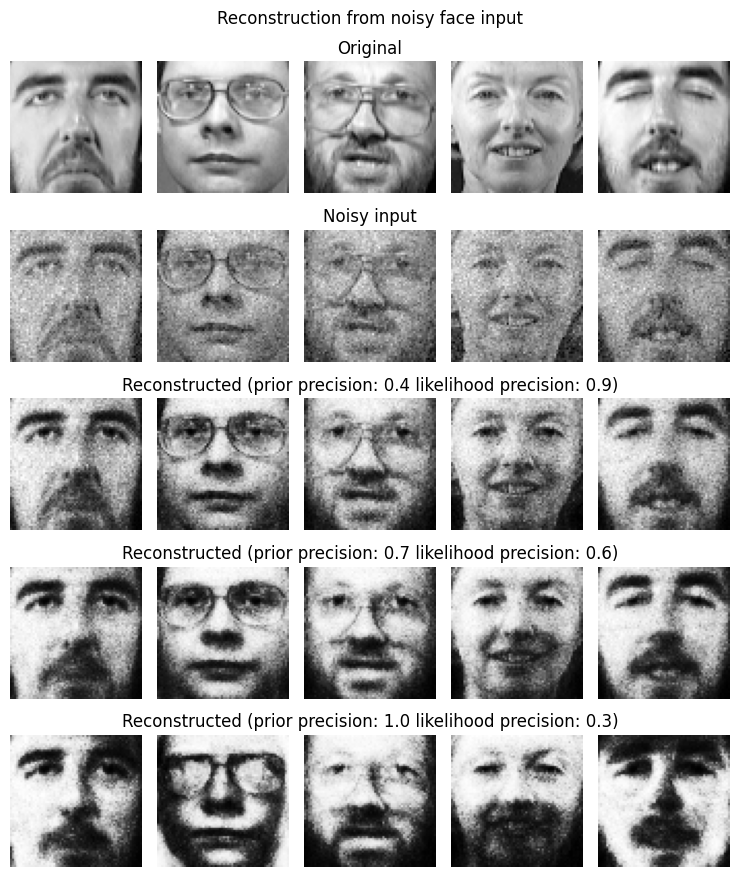

In [11]:
n_show = 5
rng_recon = np.random.default_rng(cfg["seed"] * 42)
idx_recon = rng_recon.choice(len(patterns), size=n_show, replace=False)
fig, axes = plt.subplots(5, n_show, figsize=(1.5 * n_show, 9))
for j in range(n_show):
    idx = idx_recon[j]
    orig = patterns[idx]
    axes[0, j].imshow(orig.reshape(shape), cmap="gray")
    axes[0, j].set_axis_off()
    #axes[0, j].set_title(f"Original") if j == 0 else ""
    ##################
    infer_beta = 0.4
    signal_strength = 2.0
    noisy, recon = reconstruct_one(jnet, orig, noise_std=0.5, signal_strength=signal_strength, infer_beta=infer_beta, seed=int(rng_recon.integers(0, 1e6)))
    axes[1, j].imshow(noisy.reshape(shape), cmap="gray")
    #axes[1, j].set_title(f"Noisy input") if j == 0 else ""
    axes[1, j].set_axis_off()
    
    axes[2, j].imshow(recon.reshape(shape), cmap="gray")
    #axes[2, j].set_title(f"Reconstructed (prior precision: {infer_beta} likelihood precision: {signal_strength})", loc='left') if j == 0 else ""
    axes[2, j].set_axis_off()
    ##################
    infer_beta = 0.7
    signal_strength = 1.0
    noisy, recon = reconstruct_one(jnet, orig, noise_std=0.5, signal_strength=signal_strength, infer_beta=infer_beta, seed=int(rng_recon.integers(0, 1e6)))
    axes[3, j].imshow(recon.reshape(shape), cmap="gray")
    #axes[3, j].set_title(f"Reconstructed (prior precision: {infer_beta} likelihood precision: {signal_strength})", loc='left') if j == 0 else ""
    axes[3, j].set_axis_off()
    ##################
    infer_beta = 1.0
    signal_strength = 0.5
    noisy, recon = reconstruct_one(jnet, orig, noise_std=0.5, signal_strength=signal_strength, infer_beta=infer_beta, seed=int(rng_recon.integers(0, 1e6)))
    axes[4, j].imshow(recon.reshape(shape), cmap="gray")
    #axes[4, j].set_title(f"Reconstructed (prior precision: {infer_beta} likelihood precision: {signal_strength})", loc='left') if j == 0 else ""
    axes[4, j].set_axis_off()
    
axes[0, 2].set_title("Original")
axes[1, 2].set_title("Noisy input")
axes[2, 2].set_title(f"Reconstructed (prior precision: 0.4 likelihood precision: 0.9)")
axes[3, 2].set_title(f"Reconstructed (prior precision: 0.7 likelihood precision: 0.6)")
axes[4, 2].set_title(f"Reconstructed (prior precision: 1.0 likelihood precision: 0.3)")
plt.suptitle("Reconstruction from noisy face input")
plt.tight_layout(pad=0.02, w_pad=0.02, h_pad=0.02)
plt.show()

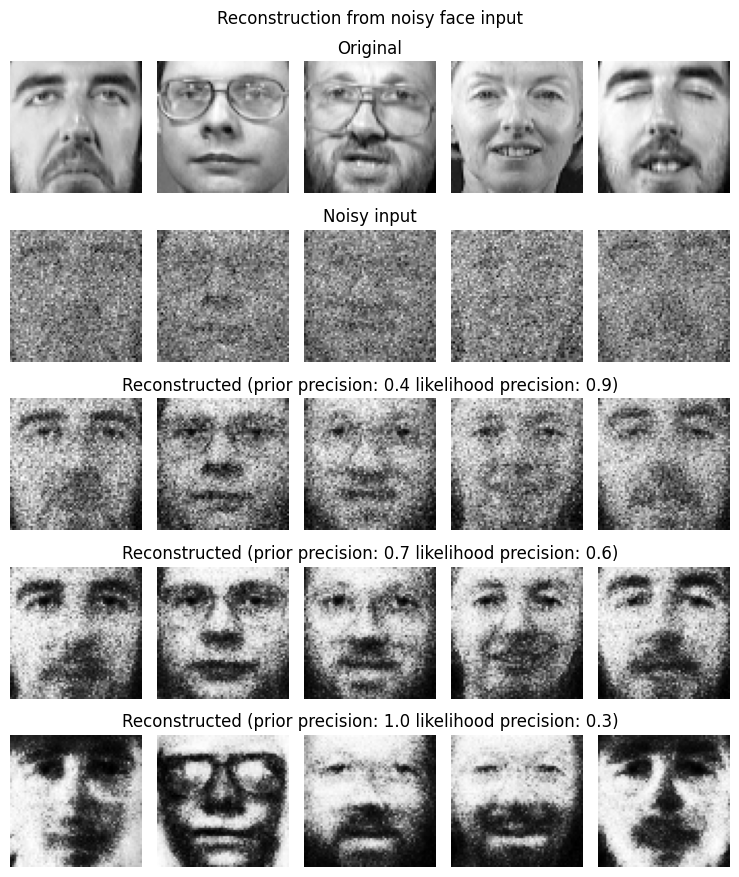

In [12]:
n_show = 5
rng_recon = np.random.default_rng(cfg["seed"] * 42)
idx_recon = rng_recon.choice(len(patterns), size=n_show, replace=False)
fig, axes = plt.subplots(5, n_show, figsize=(1.5 * n_show, 9))
for j in range(n_show):
    idx = idx_recon[j]
    orig = patterns[idx]
    axes[0, j].imshow(orig.reshape(shape), cmap="gray")
    axes[0, j].set_axis_off()
    #axes[0, j].set_title(f"Original") if j == 0 else ""
    ##################
    infer_beta = 0.4
    signal_strength = 0.9
    noisy, recon = reconstruct_one(jnet, orig, noise_std=2.0, signal_strength=signal_strength, infer_beta=infer_beta, seed=int(rng_recon.integers(0, 1e6)))
    axes[1, j].imshow(noisy.reshape(shape), cmap="gray")
    #axes[1, j].set_title(f"Noisy input") if j == 0 else ""
    axes[1, j].set_axis_off()
    
    axes[2, j].imshow(recon.reshape(shape), cmap="gray")
    #axes[2, j].set_title(f"Reconstructed (prior precision: {infer_beta} likelihood precision: {signal_strength})", loc='left') if j == 0 else ""
    axes[2, j].set_axis_off()
    ##################
    infer_beta = 0.7
    signal_strength = 0.6
    noisy, recon = reconstruct_one(jnet, orig, noise_std=2.0, signal_strength=signal_strength, infer_beta=infer_beta, seed=int(rng_recon.integers(0, 1e6)))
    axes[3, j].imshow(recon.reshape(shape), cmap="gray")
    #axes[3, j].set_title(f"Reconstructed (prior precision: {infer_beta} likelihood precision: {signal_strength})", loc='left') if j == 0 else ""
    axes[3, j].set_axis_off()
    ##################
    infer_beta = 1.0
    signal_strength = 0.3
    noisy, recon = reconstruct_one(jnet, orig, noise_std=2.0, signal_strength=signal_strength, infer_beta=infer_beta, seed=int(rng_recon.integers(0, 1e6)))
    axes[4, j].imshow(recon.reshape(shape), cmap="gray")
    #axes[4, j].set_title(f"Reconstructed (prior precision: {infer_beta} likelihood precision: {signal_strength})", loc='left') if j == 0 else ""
    axes[4, j].set_axis_off()
    
axes[0, 2].set_title("Original")
axes[1, 2].set_title("Noisy input")
axes[2, 2].set_title(f"Reconstructed (prior precision: 0.4 likelihood precision: 0.9)")
axes[3, 2].set_title(f"Reconstructed (prior precision: 0.7 likelihood precision: 0.6)")
axes[4, 2].set_title(f"Reconstructed (prior precision: 1.0 likelihood precision: 0.3)")
plt.suptitle("Reconstruction from noisy face input")
plt.tight_layout(pad=0.02, w_pad=0.02, h_pad=0.02)
plt.show()

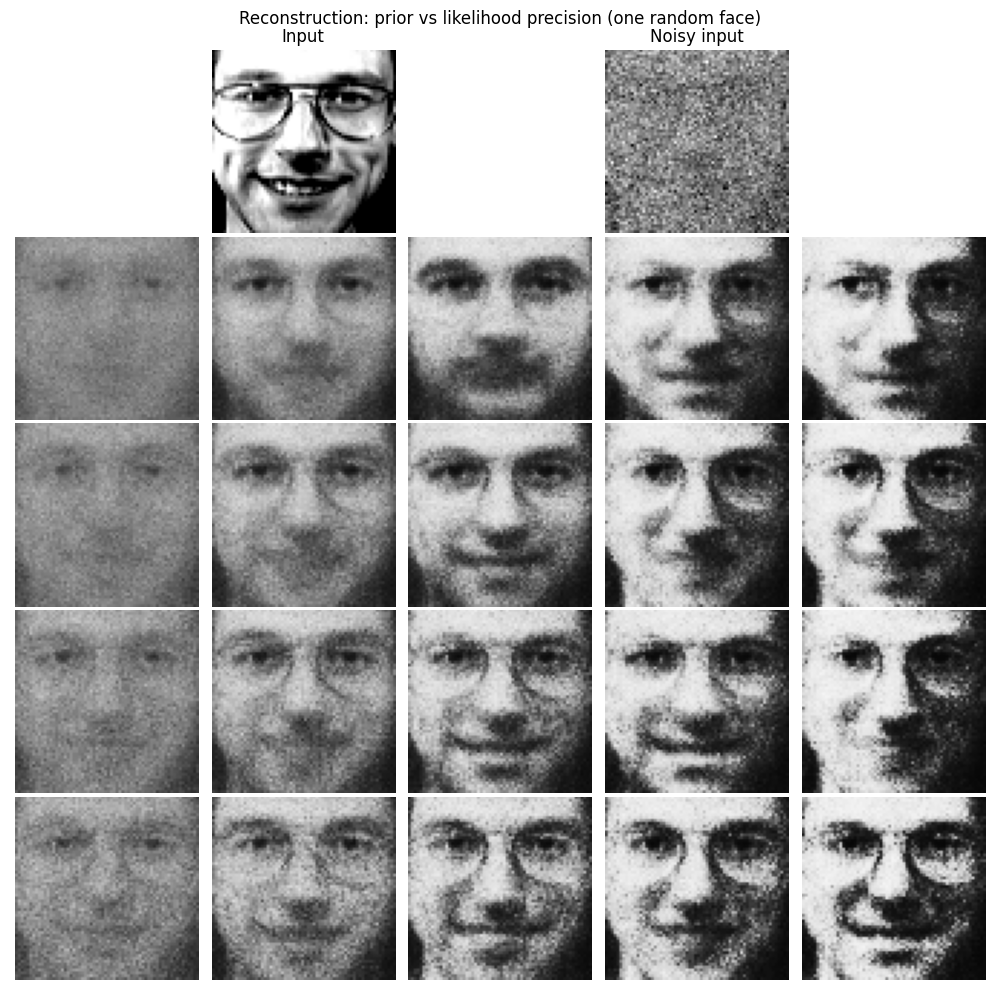

In [33]:
# 5x5 plot: row 0 = [empty, input, empty, noisy, empty]; rows 1-4 = 4x5 grid (rows = input precision, cols = prior precision)
rng_6x5 = np.random.default_rng(cfg["seed"] + 42)
idx_one = rng_6x5.choice(len(patterns))
orig_one = patterns[idx_one]
noise_std_one = 2.0
signal_for_noisy = 1.0
noisy_one, _ = reconstruct_one(
    jnet, orig_one, noise_std=noise_std_one, signal_strength=signal_for_noisy,
    infer_beta=0.6, seed=int(rng_6x5.integers(0, 1e6))
)

signal_strengths = [0.1, 0.2, 0.3, 0.4]       # input (likelihood) precision → rows
prior_betas = [0.4, 0.6, 0.8, 1.0, 1.2]       # prior precision → columns
recons_4x5 = np.zeros((4, 5, orig_one.size))
for i, sig in enumerate(signal_strengths):
    for j, infer_beta in enumerate(prior_betas):
        _, recon = reconstruct_one(
            jnet, orig_one, noise_std=noise_std_one, signal_strength=sig,
            infer_beta=infer_beta, steps=100, burn_in=10, seed=int(rng_6x5.integers(0, 1e6))
        )
        recons_4x5[i, j] = recon

fig, axes = plt.subplots(5, 5, figsize=(2 * 5, 2 * 5))
for c in range(5):
    axes[0, c].set_axis_off()
axes[0, 1].imshow(orig_one.reshape(shape), cmap="gray", vmin=-1, vmax=1)
axes[0, 1].set_axis_off()
axes[0, 3].imshow(noisy_one.reshape(shape), cmap="gray")
axes[0, 3].set_axis_off()
for i in range(4):
    for j in range(5):
        axes[i + 1, j].imshow(recons_4x5[i, j].reshape(shape), cmap="gray", vmin=-1, vmax=1)
        axes[i + 1, j].set_axis_off()
axes[0, 1].set_title("Input")
axes[0, 3].set_title("Noisy input")
plt.suptitle("Reconstruction: prior vs likelihood precision (one random face)")
fig.subplots_adjust(left=0.01, right=0.99, top=0.94, bottom=0.01, wspace=0.02, hspace=0.02)
plt.show()

## 6. Summary

- **Retention**: Stored face patterns are fixed points (attractors) of the deterministic dynamics; retention correlation summarizes how well the network holds each pattern under free run.
- **Reconstruction**: When the network receives a noisy version of a stored face as continuous bias, stochastic inference pulls activity toward the corresponding attractor; the reconstructed image (mean activity) typically correlates better with the original than the noisy input does (positive reconstruction gain).